# Homework 1: Autoregressive Models and Normalizing Flows

## Task 1: Theory (5 pt)

### Problem 1: f-divergence (1 pt)

Generative modeling can be viewed as minimizing a divergence between the data distribution $p_{\text{data}}$ and the model $p_{\boldsymbol{\theta}}$. One useful family is the $f$-divergence:

$$
D_f(p_{\text{data}}\|p_{\boldsymbol{\theta}})=\mathbb{E}_{p_{\boldsymbol{\theta}}}\left[f\left(\frac{p_{\text{data}}(\mathbf{x})}{p_{\boldsymbol{\theta}}(\mathbf{x})}\right)\right].
$$

Here $f$ is convex on $(0,\infty)$ and $f(1)=0$. For (a)–(b), assume that both densities are positive on the same domain and all integrals are finite.

**(a)** Find $f$ for forward KL, $D_{\mathrm{KL}}(p_{\text{data}}\|p_{\boldsymbol{\theta}})$, and reverse KL, $D_{\mathrm{KL}}(p_{\boldsymbol{\theta}}\|p_{\text{data}})$. Check convexity and $f(1)=0$.

**(b)** Use Jensen's inequality to show that $D_f\geq0$. Does $D_f=0$ always mean that the distributions coincide? Check the example $f(u)=u-1$.

*For strictly convex $f$, zero divergence does imply identical distributions; you may use this fact without proof.*

**(c)** Consider $p_{\text{data}}=\mathrm{Uniform}(0,2)$ and $p_{\boldsymbol{\theta}}=\mathrm{Uniform}(0,1)$. Compute forward and reverse KL. What does the example tell you about a model that assigns zero probability to part of the data range?

*In KL, a region with positive numerator density and zero denominator density contributes $+\infty$; regions where the numerator density is zero contribute $0$.*

```
your solution
```

**(a)** For forward KL:
$$
D_{\rm KL}(p_{\rm data} || p_\theta) = \int p_{\rm data}(x) \log \frac{p_{\rm data}(x)}{p_\theta(x)} dx = \int \frac{p_{\rm data}(x)}{p_\theta(x)} \log \frac{p_{\rm data}(x)}{p_\theta(x)} p_\theta(x) dx =
\mathbb{E}_{p_\theta} \Bigl[\frac{p_{\rm data}(x)}{p_\theta(x)} \log \frac{p_{\rm data}(x)}{p_\theta(x)}\Bigr]
$$
Hence, $f(x) = x \log x$. Convexity on $(0, \infty)$ follows from:
$$
f'(x) = \log x + 1 \Rightarrow f''(x) = \frac{1}{x} > 0 \Rightarrow f \text{ is convex}
$$
And $f(1) = 0.$

For reverse KL:
$$
D_{\rm KL}(p_\theta || p_{\rm data}) = \mathbb{E}_{p_\theta}\Bigl[\log \frac{p_\theta(x)}{p_{\rm data}(x)}\Bigr]
$$
So, here $f(x) = - \log(x)$. $f$ is convex as $\log(x)$ is concave, and $f(1) = 0$.

**(b)** Using Jensen's inequality:
$$
D_f = \mathbb{E}_{p_\theta} \Bigl[ f(\frac{p_{\rm data}(x)}{p_\theta(x)}) \Bigr] \geq f(\mathbb{E}_{p_\theta}\Bigl[\frac{p_{\rm data}(x)}{p_\theta} \Bigr]) = f(\int \frac{p_{\rm data}(x)}{p_\theta(x)} p_\theta(x)dx) = f(\int p_{\rm data}(x) dx) = f(1) = 0
$$
Let's consider $f(u) = u - 1$. For any eligible $p_{\rm data}$ and $p_\theta$:
$$
D_f = \mathbb{E}_{p_\theta} \Bigl[\frac{p_{\rm data}(x)}{p_\theta(x)} - 1 \Bigr] = \int p_{\rm data}(x)dx - 1 = 1 - 1 = 0
$$
Therefore, $D_f=0$ doesn't mean that $p_{\rm data}$ and $p_\theta$ are necessary coincide.

**(c)** Forward KL:

$$
D_{\rm KL}(p_{\rm data} || p_\theta) = \int \text{Unif}(0,2) \log \tfrac{\text{Unif}(0,2)}{\text{Unif}(0, 1)}dx = \int_{[0, 2]}\tfrac{1}{2}\log \tfrac{1/2}{\mathbb{I}_{[0,1]}(x)} dx = \int_{[0, 1]}\tfrac{1}{2}\log \tfrac{1/2}{\mathbb{I}_{[0,1]}(x)} dx + \int_{[1, 2]}\tfrac{1}{2}\log \tfrac{1/2}{\mathbb{I}_{[0,1]}(x)} dx \\
= \int_{[0, 1]}\tfrac{1}{2} \log \tfrac{1}{2} dx + \int_{[1, 2]}\tfrac{1}{2}\log \tfrac{1/2}{0} = \tfrac{1}{2} \log \tfrac{1}{2} + \infty = \infty
$$

Reverse KL:
$$
D_{\rm KL}(p_\theta || p_{\rm data}) = \int \text{Unif}(0,1) \log \tfrac{\text{Unif(0,1)}}{\text{Unif}(0,2)} = \int_{[0,1]} \log \tfrac{1}{1/2} dx = \log 2
$$

As we discussed, the minimization of forward KL is equivalent to maximization of the likelihood in some sense. So, the infinite forward KL divirgence tell us that likelihood of data is equal zero. Indeed, our model assigns zero probability to part of the data range, which doesn't describe factual data distribution at all.

### Problem 2: Curse of dimensionality — volume near the boundary (1 pt)

In Lecture 1, we discussed the **curse of dimensionality** when modeling high-dimensional data such as images. This problem develops geometric intuition for that discussion: a region that looks thin can contain a large fraction of the volume in high dimensions.

Consider a solid ball of radius $1$ in $\mathbb R^m$. Its outer shell of thickness $\varepsilon$ consists of the points whose distance from the center is between $1-\varepsilon$ and $1$. Let $\Delta_m(\varepsilon)$ denote the fraction of the ball's volume contained in this shell. Equivalently, it is the probability that a uniformly sampled point falls in the shell.

Write $V_m(r)$ for the volume of an $m$-dimensional ball of radius $r$. You may use
$$
V_m(r)=C_m r^m,
$$
where $C_m>0$ depends only on the dimension. You will not need its explicit value.

**(a) A shell of fixed thickness (0.2 pt).** Express $\Delta_m(\varepsilon)$ using the volumes $V_m(1)$ and $V_m(1-\varepsilon)$, and simplify the result. What happens to this fraction as $m\to\infty$ if $0<\varepsilon<1$ stays fixed?

**(b) Capturing 90% of the volume (0.4 pt).** How thin can the outer shell be while still containing 90% of the ball's volume? Use (a) to find the thickness $\varepsilon_m$ for which $\Delta_m(\varepsilon_m)=0.9$. Then obtain a simple approximation for $\varepsilon_m$ when $m$ is large, including its constant factor.

*Useful limit: you may use $\displaystyle\lim_{t\to0}\frac{e^t-1}{t}=1$.*

**(c) Can a shell be too thin? (0.4 pt).** Now let the shell become thinner as the dimension grows: choose $\varepsilon_m\in(0,1)$ with $\varepsilon_m\to0$. Does the conclusion $\Delta_m(\varepsilon_m)\to1$ from (a) hold for every such choice? If not, give an explicit formula for a thickness $\varepsilon_m$ whose volume fraction tends to **zero**, and prove this using your expression from (a). Explain why this does not contradict (a).

```
your solution
```

**(a)**

$$
\Delta_m(\varepsilon) = \frac{V_m(1) - V_m(1 - \varepsilon)}{V_m(1)} = \frac{C_m - C_m (1 - \varepsilon)^m}{C_m} = 1 - (1 - \varepsilon)^m \to 1, m \to \infty
$$

**(b)**

$$
\Delta_m(\varepsilon_m) = 0.9 \Rightarrow 1 - (1 - \varepsilon_m)^m = 0.9 \Rightarrow \varepsilon_m = 1 - (1 - 0.9)^\frac{1}{m} = 1 - 0.1^\frac{1}{m}
$$
From the limit $\displaystyle\lim_{t\to0}\frac{e^t-1}{t}=1$ we know $e^t - 1 \sim t, \ t \to 0$.
$$
1 - 0.1^\frac{1}{m} = 1 - e^{\tfrac{1}{m} \log 0.1} \sim -\frac{1}{m} \log 0.1 = \frac{1}{m} \log 10, \ m \to \infty
$$
Therefore, when m is large $\varepsilon_m$ can be approximated as $\frac{1}{m} \log 10$.

**(c)**

Let $\varepsilon_m = \frac{1}{e^m}$. Then from (a): $\Delta_m(\varepsilon_m) = 1 - (1 - \frac{1}{e^m})^m = 1 - (1 - e^{-m})^m$. 

$$
(1 - e^{-m})^m = e^{m \log (1 - e^{-m})} = e^{f(m)}
$$
Let's find limit of $f(m)$.
$$
f(m) = m \log(1 - e^{-m})= -m e^{-m} \frac{\log(1 - e^{-m})}{-e^{-m}} = -\frac{m}{e^{m}} \cdot \frac{\log(1 - e^{-m})}{- e^{-m}}
$$
Make a substitution: $t = \log(1 - e^{-m})$. Then $-e^{-m} = e^t - 1$. Hence,
$$
\lim_{n \to \infty} \frac{\log(1 - e^{-m})}{- e^{-m}} = \lim_{t \to 0} \frac{t}{e^t - 1} = 1
$$
We also know $-\frac{m}{e^{m}} \to 0$. Put all together: $f(m) \to 0, m \to \infty$. And finally:

$$
1 - (1 - e^{-m})^m \to 1 - e^0 = 0, m \to \infty
$$

This doesn't contradic (a), since the limit of 1 for $\Delta_m (\varepsilon)$ was proven only under the condition that $\varepsilon$ is fixed. In this case, in task (c), $\varepsilon$ tends to zero.

### Problem 3: Expressivity of normalizing flows (3 pts)

Can we turn a simple distribution into a more complicated one using an invertible transformation? We will build such a transformation using conditional CDFs.

Let $p_{\text{data}}(\mathbf{x})$ be a positive density on $\mathbb{R}^m$. Use its autoregressive decomposition and define

$$
p_{\text{data}}(\mathbf{x})=\prod_{j=1}^mp_{\text{data}}(x_j\mid\mathbf{x}_{1:j-1}).
$$

$$
F_j(x_j,\mathbf{x}_{1:j-1})=\int_{-\infty}^{x_j}p_{\text{data}}(t\mid\mathbf{x}_{1:j-1})\,dt.
$$

Assume the conditional densities are positive and the conditional CDFs are continuously differentiable in all their arguments.

Combine them into

$$
F:\mathbb{R}^m\to(0,1)^m,\qquad
F(\mathbf{x})=\big(F_1(x_1),\ldots,F_m(x_m,\mathbf{x}_{1:m-1})\big).
$$

**(a)** Show that the Jacobian is lower triangular and $\det J_F(\mathbf{x})=p_{\text{data}}(\mathbf{x})$.

**(b)** Explain how to recover $x_1$, then $x_2$, and so on from any $\mathbf{u}\in(0,1)^m$. Why is each step possible and its answer unique?

**(c)** Use the density change-of-variables formula to show that $F(\mathbf{X})$ is uniform on $(0,1)^m$ when $\mathbf{X}\sim p_{\text{data}}$.

**(d)** Let $\mu$ be another density satisfying the same assumptions. Using $F_{\text{data}}$ and $F_\mu$, construct an invertible transformation that turns samples from $p_{\text{data}}$ into samples from $\mu$.

```
your solution
```

**(a)**

Consider the case $j > i$. The following partial derivative is zero:
$$
\frac{\partial F_i(x_i, x_{1:i-1})}{\partial x_j} = 0
$$
as $F_i(x_i, x_{1:i-1})$ doesn't depend of $x_j$ for $j > i$. That is why Jacobian is lower triangular. Next, by fundamental theorem of calculus:
$$
\frac{\partial F_i(x_i, x_{1:i-1})}{\partial x_i} = \frac{\partial}{\partial x_i} \int_{-\infty}^{x_i} p_{\rm data}(t | x_{1:i-1}) dt = p_{\rm data}(x_i | x_{1:i-1})
$$
As the jacobian is triangular, its determinant is expressed as
$$
\text{det} J_F(x) = \prod_{i=1}^m \frac{\partial F_i(x_i, x_{1:i-1})}{\partial x_i} = \prod_{i=1}^m p_{\rm data}(x_i | x_{1:i-1}) = p_{\rm data}(x)
$$

**(b)** In order to find all $x_i$ we should solve system of $m$ equations:
$$
F_i(x_i, x_{1:i-1}) = u_i
$$
For each $i$, we know that $\lim_{x_i \to +\infty} F_i(x_i, x_{1:i-1}) = 1$, $\lim_{x_i \to -\infty} F_i(x_i, x_{1:i-1}) = 0$, and $F_i$ is continuous of $x_i$. Therefore, by intermediate value theorem, for an arbitrary $u_i \in (0,1)$ exists a point $x_i$ such that $F_i(x_i, x_{1:i-1}) = u_i$. Moreover, as density is positive
$$
\frac{\partial}{\partial x_i} F_i(x_i, x_{1:i-1}) = p_{\rm data}(x_i | x_{1:i-1}) > 0
$$
This means that the found point $x_i$ is unique. So, we can write $x_i = F_i^{-1}(u_i, x_{1:i-1})$. Therefore, recovering from $u$ is
$$
x_1 = F_1^{-1}(u_1)\\
x_2 = F_2^{-1}(u_2, x_1) \\
\vdots \\
x_m = F_m^{-1}(u_m, x_{1:m-1})
$$

**(c)** Using CoV theorem ($F$ is bijective):
$$
p_{\rm data}(x) = p_{U}(F(x)) \cdot | \text{det} J_F(x) | \Rightarrow p_{U}(F(x)) = \frac{p_{\rm data}(x)}{\text{det} J_F(x)}
$$
From (a): $\text{det} J_F(x) = p_{\rm data}(x)$, thus:
$$
p_{U}(u) = \frac{p_{\rm data}(F^{-1}(u))}{p_{\rm data}(F^{-1}(u))} = 1
$$
Therefore, $U \sim \text{Uniform}( (0,1)^m)$


**(d)**

For both distributions $p_{\rm data}$ and $\mu$ the vectors, transformed by $F$, have a uniform distrubution on $(0, 1)^m$. Thus, we can sample a data point from $p_{\rm data}$, then transform it into uniform space of vectors $u$, and finally transform it back using $F_\mu^{-1}$. Formally:

$$
X_{\rm data} \sim p_{\rm data} \Rightarrow X_\mu = F^{-1}_\mu(F_{\rm data}(X_{\rm data})) \sim \mu
$$

It works because $F_{\rm data}$ and $F_\mu^{-1}$ are bijective.

Now it time to move on to practical part of homework.

In our course we will use a small util [package](https://github.com/r-isachenko/dgm_utils) with some usefull functions for loading and visualizing the images and training curves. In each homework there will be a cell with installing this package. Please read carefully the sources of the functions from this package. It could help you to solve the tasks.

In [1]:
COMMIT_HASH = "b8b4de3057ea4cafc3f263bfcf314f679b637db1"
!if [ -d dgm_utils ]; then rm -Rf dgm_utils; fi
!git clone https://github.com/r-isachenko/dgm_utils.git
%cd dgm_utils
!git checkout {COMMIT_HASH}
!pip install ./
%cd ./..
!rm -Rf dgm_utils

Cloning into 'dgm_utils'...
remote: Enumerating objects: 228, done.
remote: Counting objects: 100% (228/228), done.
remote: Compressing objects: 100% (172/172), done.
remote: Total 228 (delta 148), reused 107 (delta 55), pack-reused 0 (from 0)
Receiving objects: 100% (228/228), 55.60 KiB | 933.00 KiB/s, done.
Resolving deltas: 100% (148/148), done.
/content/dgm_utils
Note: switching to 'b8b4de3057ea4cafc3f263bfcf314f679b637db1'.

You are in 'detached HEAD' state. You can look around, make experimental
changes and commit them, and you can discard any commits you make in this
state without impacting any branches by switching back to a branch.

If you want to create a new branch to retain commits you create, you may
do so (now or later) by using -c with the switch command. Example:

  git switch -c <new-branch-name>

Or undo this operation with:

  git switch -

Turn off this advice by setting config variable advice.detachedHead to false

HEAD is now at b8b4de3 Fix AMP gradient clipping b

In [2]:
from dgm_utils import train_model
from dgm_utils import show_samples, visualize_images, load_dataset
from dgm_utils import BaseModel

In [3]:
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data

if torch.cuda.is_available():
    DEVICE = "cuda"
    print('GPU found :)')
else:
    DEVICE = "cpu"
    print('GPU not found :(')

GPU found :)


## Task 2: ImageGPT on MNIST (3 pts)

In this task you will try to implement the Image Transformer net for an autoregressive generation MNIST images. See the [blog](https://openai.com/blog/image-gpt/) and [paper](https://cdn.openai.com/papers/Generative_Pretraining_from_Pixels_V2.pdf) for details.

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.55MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 132kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.21MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.02MB/s]


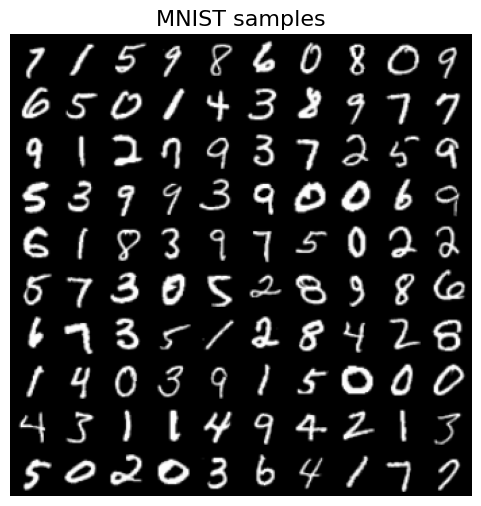

In [33]:
train_data, _, test_data, _ = load_dataset(
    "mnist", flatten=False, binarize=False)
train_data, test_data = (
    train_data * 255).astype(int), (test_data * 255).astype(int)
visualize_images(train_data, "MNIST samples")

### Architecture

Let start with **the multihead attention block**. Each head of the multihead attention computes an embedding
$$
    \text{Attention}(\mathbf{Q}, \mathbf{K}, \mathbf{V}) = \text{softmax}\left(\frac{\mathbf{Q}\mathbf{K}^T}{\sqrt{d_k}}\right) \mathbf{V},
$$
where $\mathbf{Q}, \mathbf{K}, \mathbf{V}$ - query/key/value matrices obtained using Linear projection of $\mathbf{h}^l$.

**To make the model autoregressive** we will introduce the following changes:

1. We will apply the upper triangular mask to the matrix of attention logits ($\mathbf{Q}\mathbf{K}^T$). Masked values are made close to minus infinity so they will turn zero after softmax.
2. During training we will add "start of sequence" token to the input tensor and pop the last pixel.

Note: we will use raster order to identify which pixels come first. For each pixel the predicted probabality is conditioned on all the previous pixels.

In [6]:
class MultiheadAttention(nn.MultiheadAttention):
    def __init__(self, embed_dim: int, num_heads: int) -> None:
        super().__init__(embed_dim, num_heads)

    def get_attention_mask(self, x: torch.Tensor) -> torch.Tensor:
        # ====
        # your code
        # define attention mask, it should contain
        # - zeros under and on the main diagonal
        # - minus Inf above the main diagonal
        return torch.triu(-np.inf * torch.ones(x.shape[0], x.shape[0], device=x.device), diagonal=1)
        # ====

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        attn_mask = self.get_attention_mask(x)
        return super().forward(x, x, x, attn_mask=attn_mask, need_weights=False)[0]


def test_attention_mask() -> None:
    x = torch.zeros(2, 4, 16)  # (pixel_num, batch_size, emb_dim)
    mask = np.array([[0.0, -np.inf], [0.0, 0.0]])
    layer = MultiheadAttention(16, 8)
    attention_mask = layer.get_attention_mask(x)
    assert attention_mask.size() == (x.size(0), x.size(0))
    assert np.allclose(attention_mask.numpy(), mask)
    out = layer(x)
    assert x.size() == out.size()


test_attention_mask()

Now we will define **the decoder block** which transforms the tensor as follows:
\begin{gather}
    \mathbf{n}^l = \text{layer\_norm}_1\left(\mathbf{h}^l\right), \notag \\
    \mathbf{a}^l = \mathbf{h}^l + \text{multihead\_attention}\left(\mathbf{n}^l\right), \notag \\
    \mathbf{h}^{l+1} = \mathbf{a}^l + \text{MLP}\left(\text{layer\_norm}_2\left(a^l\right)\right). \notag
\end{gather}

The $l^{\text{th}}$ block receives a tensor $\mathbf{h}^l$ with shape `(pixel_num, batch_size, emb_dim)` where `pixel_num` is a total number of pixels $(32 \times 32)$ and `emb_dim` is a hyperparameter for the size of the embeddings.

In [7]:
class TransformerBlock(nn.Module):
    def __init__(self, embed_dim: int, num_heads: int) -> None:
        super().__init__()
        assert embed_dim % num_heads == 0

        # ====
        # your code
        # define basic layers of Transformer:
        # 1. our masked MultiheadAttention
        # 2. LayerNorm (https://pytorch.org/docs/stable/generated/torch.nn.LayerNorm.html)
        # 3. some MLP

        # ====
        self.mha = MultiheadAttention(embed_dim, num_heads)
        self.ln_mha = nn.LayerNorm(embed_dim)
        self.ln_mlp = nn.LayerNorm(embed_dim)
        hidden_dim = 128
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, embed_dim)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # ====
        # your code
        # here you have to implement formulas that described above.
        a = x + self.mha(self.ln_mha(x))
        x = a + self.mlp(self.ln_mlp(a))
        # ====
        return x


def test_decoder_block() -> None:
    block = TransformerBlock(embed_dim=12, num_heads=4)
    x = torch.zeros(4, 28, 12)
    assert x.shape == block(x).shape


test_decoder_block()

Finally, let's construct the Image Transformer. It consists of $L$ sequentially applied decoder blocks.

The initial embedding $h^1$ is the sum of the token embedding of the input batch and a trainable positional embedding, with a "start of sequence" token prepended. 

After passing through the last decoder block, we apply `nn.LayerNorm` followed by a `nn.Linear` layer to produce logits of shape `(pixel_num, batch_size, 256)` (256 for each pixel):

$$
\begin{align*}
  n^L &= \text{layer\_norm}\left(h^L\right) \\
  \text{logits} &= \text{linear}\left(n^L\right)
\end{align*}
$$

In [8]:
class ImageGPT(BaseModel):
    def __init__(
        self, input_shape: tuple[int, int], embed_dim: int, num_heads: int, num_layers: int
    ) -> None:
        super().__init__()

        self.embed_dim = embed_dim
        self.input_shape = input_shape
        self.criterion = nn.CrossEntropyLoss()

        # "start of sequence" token (we initialize it from Normal distribution)
        self.sos = nn.Parameter(0.02 * torch.randn(embed_dim))

        # ====
        # your code
        # 1) define token_embeddings (we will have 256 embeddings in total, because pixels in range [0, 255])
        # 2) define position_embeddings (we will use nn.Embedding)
        self.token_embeddings = nn.Embedding(
            num_embeddings=256, embedding_dim=embed_dim)
        self.position_embeddings = nn.Embedding(
            num_embeddings=input_shape[0] * input_shape[1], embedding_dim=embed_dim)
        # ====

        self.layers = nn.ModuleList()
        # ====
        # your code
        # 1) add decoder blocks to self.layers list
        # 2) define last LayerNorm
        # 3) define final Linear layer (without bias)
        for _ in range(num_layers):
            self.layers.append(TransformerBlock(embed_dim, num_heads))
        self.ln = nn.LayerNorm(embed_dim)
        self.lm_head = nn.Linear(embed_dim, 256, bias=False)
        # ====

    def add_sos_token(self, embeddings: torch.Tensor) -> torch.Tensor:
        batch_size = embeddings.size(1)
        # ====
        # your code
        # prepend sos (start of sequence) token
        # 1) repeat sos token batch_size times (make it of size (1, batch_size, emd_size))
        # 2) drop last embedding from embeddings
        # 3) concat repeated sos token to embeddings (after dropping)
        sos = self.sos.repeat(1, batch_size).reshape(
            1, batch_size, self.embed_dim)
        embeddings = torch.concat([sos, embeddings[:-1, ...]], dim=0)
        # ====
        return embeddings

    def add_pos_embeddings(self, embeddings: torch.Tensor) -> torch.Tensor:
        length = embeddings.size(0)
        # ====
        # your code
        # add positional embeddings
        # 1) define tensor with positions (just torch.arange) of size (length, 1)
        # 2) add position embeddings to initial embeddings
        pos_ind = torch.arange(length)[:, None].to(embeddings.device)
        embeddings = embeddings + self.position_embeddings(pos_ind)
        # ====
        return embeddings

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x.long()
        x = x.reshape(x.size(0), -1)  # (batch_size, length)
        x = x.permute(1, 0)

        embeddings = self.token_embeddings(x)  # (length, batch_size, emb_size)
        embeddings = self.add_sos_token(embeddings)
        embeddings = self.add_pos_embeddings(embeddings)

        # ====
        # your code
        # 1) apply all decoder layers
        # 2) apply final LayerNorm and Linear layer
        for layer in self.layers:
            embeddings = layer(embeddings)
        logits = self.lm_head(self.ln(embeddings))
        # ====

        # (length, batch_size, emb_size) -> (batch_size, length, emb_size)
        return logits.permute(1, 0, 2)

    def loss(self, x: torch.Tensor) -> dict:
        logits = self(x)
        loss = self.criterion(logits.reshape(-1, 256), x.reshape(-1).long())
        return {"total_loss": loss}

    @torch.no_grad()
    def sample(self, n_samples: int) -> np.ndarray:
        # read sampling carefully
        seq_len = self.input_shape[0] * self.input_shape[1]
        samples = torch.zeros(n_samples, seq_len).long().to(self.device)
        for i in range(seq_len):
            logits = self(samples)
            dist = torch.distributions.Categorical(logits=logits[:, i, :])
            samples[:, i] = dist.sample()
        samples = samples.reshape(n_samples, 1, *self.input_shape)
        return samples.cpu().numpy()


def test_image_gpt():
    batch_size, size = 8, 2
    seq_len = size * size
    embed_dim = 12
    image_gpt = ImageGPT(
        input_shape=(size, size),
        embed_dim=embed_dim,
        num_heads=4,
        num_layers=2
    )
    emb = torch.randn(seq_len, batch_size, embed_dim)
    out = image_gpt.add_sos_token(emb)
    assert torch.isclose(out[0, 0, :], image_gpt.sos).all(), \
        "First token must equal the SOS embedding for every batch element."
    assert torch.allclose(out[1:], emb[:-1]), \
        "Sequence must be shifted right by 1."

    with torch.no_grad():
        for p in range(seq_len):
            image_gpt.position_embeddings.weight[p].fill_(float(p))

    emb = torch.zeros(seq_len, batch_size, embed_dim)
    out = image_gpt.add_pos_embeddings(emb)

    for p in range(seq_len):
        expected = torch.full((batch_size, embed_dim), p, dtype=emb.dtype)
        assert torch.allclose(out[p], expected), (
            f"Position {p} must add a vector filled with {p} to all batch elements."
        )

    x = torch.randint(0, 256, size=(batch_size, seq_len))
    assert image_gpt(x).shape == torch.Size([batch_size, seq_len, 256]), \
        "Output must have shape (batch_size, seq_len, 256) for 256-class pixels."


test_image_gpt()

### Training

Now we are ready to train our model.

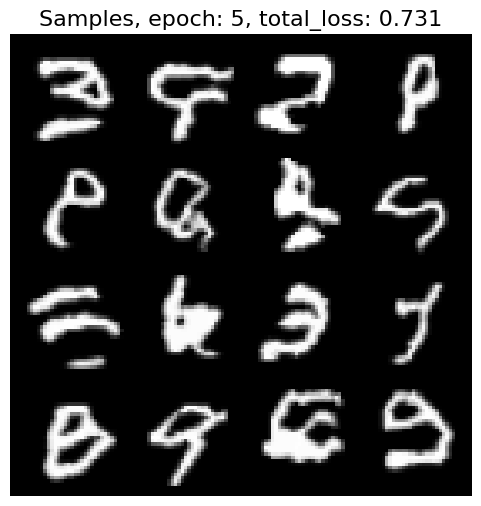

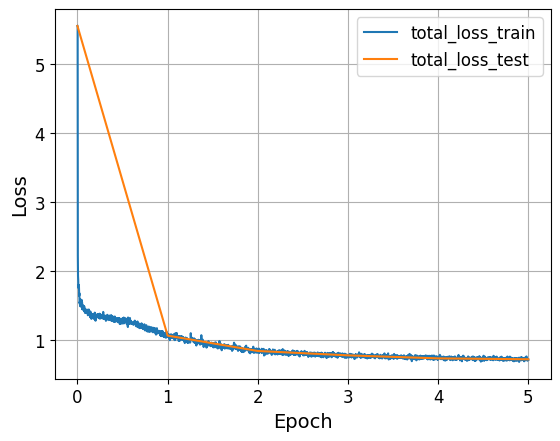

End of the training


In [ ]:
# ====
# your code
# choose these parameters
EPOCHS = 5
BATCH_SIZE = 128
LR = 5e-3

EMB_DIM = 128
NUM_HEADS = 8
NUM_LAYERS = 6
# ====

image_gpt = ImageGPT((32, 32), EMB_DIM, NUM_HEADS, NUM_LAYERS)

train_loader = data.DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
test_loader = data.DataLoader(test_data, batch_size=BATCH_SIZE)

# choose any optimizer/scheduler as you want
optimizer = torch.optim.Adam(image_gpt.parameters(), lr=LR)

train_model(
    image_gpt,
    train_loader,
    test_loader,
    epochs=EPOCHS,
    optimizer=optimizer,
    device=DEVICE,
    n_samples=16,  # Remember the inference is slow, so, you can lower the value
    # or you can turn off sampling by setting `visualize_samples=False`
    visualize_samples=True,
    use_amp=True
)

Let's generate images with the trained ImageGPT.

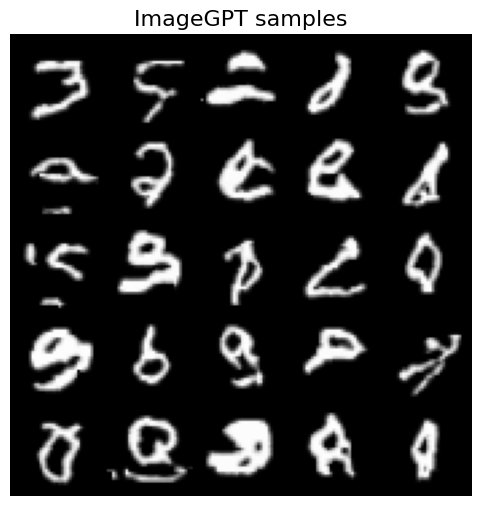

In [23]:
samples = image_gpt.sample(25)
show_samples(samples, title="ImageGPT samples", nrow=5)

## Task 3: Any-order ImageGPT (2 pts)

Interestingly, autoregressive generation need not follow the raster order used in Task 2. [DeepNADE](https://arxiv.org/abs/1310.1757) explored training across pixel permutations, and [DEformer](https://arxiv.org/abs/2106.06989) applied this idea to a Transformer. This exposes the model to a wider range of pixel contexts than a single fixed sequence.

We keep the next-pixel cross-entropy loss, but average it over generation orders. For each image, we sample a permutation $\pi$ uniformly from the permutations of its $L=H\cdot W$ pixels:
$$
    \mathcal{L}_{\text{any-order}}(\theta)
    =
    \mathbb{E}_{x}\,
    \mathbb{E}_{\pi\sim\mathrm{Uniform}(S_L)}
    \left[
    \frac{1}{L}\sum_{k=0}^{L-1}
    -\log p_\theta\left(x_{\pi_k}| x_{\pi_{<k}},\pi\right)
    \right].
$$
Uniform sampling gives every order the same chance, without choosing a preferred one in advance. One sampled order per image provides an estimate of this objective for each training batch.

### Architecture

Fortunately, we do not need to redesign ImageGPT or change its causal attention mask. We reorder each image’s pixel sequence according to $\pi$ before passing it to the model. The mask then treats $\pi_k$ as step $k$ and hides the pixels that come later in this order.

However, we do need to update the positional information. In raster order, the step number $k$ also tells us where the previous pixel and the target pixel are located. With an arbitrary order, their original image positions are $\pi_{k-1}$ and $\pi_k$. After shifting the input, the token at step $k$ contains the **value** of $x_{\pi_{k-1}}$, but the model cannot determine that pixel’s original position from $k$ alone. We therefore add a positional embedding for $\pi_{k-1}$ and use the existing positional embeddings to identify the target position $\pi_k$. At step $0$, the SOS token has no previous pixel.

In [ ]:
class AnyOrderImageGPT(ImageGPT):
    def __init__(
        self, input_shape: tuple[int, int], embed_dim: int, num_heads: int, num_layers: int
    ) -> None:
        super().__init__(input_shape, embed_dim, num_heads, num_layers)

        # ====
        # your code
        # define an embedding for the position of the previous pixels
        # (same as self.position_embeddings in ImageGPT class)
        self.permute_embeddings = nn.Embedding(
            num_embeddings=input_shape[0] * input_shape[1], embedding_dim=embed_dim)
        # ====

    def add_pos_embeddings(
        self, embeddings: torch.Tensor, order: torch.Tensor
    ) -> torch.Tensor:
        # ====
        # your code
        # add positional embeddings
        # 1) transpose order to match the Transformer's (length, batch_size) layout
        # 2) add embeddings of the original positions of pixels being predicted
        # 3) embed all positions except the last to identify previously observed pixels
        # 4) prepend zeros for SOS, then add these previous-position embeddings
        order = order.permute(1, 0)
        batch_size = order.shape[1]
        # (length, batch_size, emb_dim)
        embeddings = embeddings + self.position_embeddings(order)
        perm_emb = self.permute_embeddings(order[:-1, :])
        perm_emb = torch.concat([torch.zeros(
            1, batch_size, self.embed_dim, device=embeddings.device), perm_emb], dim=0)
        embeddings = embeddings + perm_emb
        # ====
        return embeddings

    def forward(self, x: torch.Tensor, order: torch.Tensor) -> torch.Tensor:
        x = x.long()
        x = x.reshape(x.size(0), -1)  # (batch_size, length)
        # ====
        # your code
        # arrange pixels in generation order
        # this would make us reuse the same implementation
        # of causal attention
        x = x.gather(1, order)
        # ====
        x = x.permute(1, 0)

        embeddings = self.token_embeddings(x)  # (length, batch_size, emb_size)
        embeddings = self.add_sos_token(embeddings)
        embeddings = self.add_pos_embeddings(embeddings, order)

        # ====
        # your code
        # 1) apply all decoder layers
        # 2) apply final LayerNorm and Linear layer
        for layer in self.layers:
            embeddings = layer(embeddings)
        logits = self.lm_head(self.ln(embeddings))
        # ====

        # (length, batch_size, emb_size) -> (batch_size, length, emb_size)
        return logits.permute(1, 0, 2)

    def loss(self, x: torch.Tensor) -> dict:
        batch_size = x.size(0)
        seq_len = self.input_shape[0] * self.input_shape[1]

        # we use raster order for evaluation
        if self.training:
            order = torch.rand(batch_size, seq_len,
                               device=x.device).argsort(dim=1)
        else:
            order = torch.arange(
                seq_len, device=x.device).expand(batch_size, -1)

        logits = self(x, order)
        targets = x.reshape(batch_size, -1).long()
        # ====
        # your code
        # arrange targets in order that we just sampled
        # this would make us reuse the same implementation
        # of causal attention
        targets = targets.gather(1, order)
        # ====
        loss = self.criterion(logits.reshape(-1, 256), targets.reshape(-1))
        return {"total_loss": loss}

    @torch.no_grad()
    def sample(self, n_samples: int) -> np.ndarray:
        # read sampling carefully
        seq_len = self.input_shape[0] * self.input_shape[1]
        samples = torch.zeros(n_samples, seq_len).long().to(self.device)
        order = torch.rand(n_samples, seq_len,
                           device=samples.device).argsort(dim=1)
        for i in range(seq_len):
            logits = self(samples, order)
            dist = torch.distributions.Categorical(logits=logits[:, i, :])
            samples.scatter_(1, order[:, i:i + 1], dist.sample().unsqueeze(1))
        samples = samples.reshape(n_samples, 1, *self.input_shape)
        return samples.cpu().numpy()


def test_any_order_image_gpt() -> None:
    batch_size, size = 1, 2
    seq_len = size * size
    model = AnyOrderImageGPT(
        input_shape=(size, size),
        embed_dim=12,
        num_heads=4,
        num_layers=2,
    )
    model.eval()
    x = torch.tensor([[[1, 2], [3, 4]]])
    order = torch.tensor([[2, 0, 3, 1]])
    logits = model(x, order)
    assert logits.shape == (batch_size, seq_len, 256)

    for k in range(seq_len):
        changed = x.reshape(batch_size, -1).clone()
        future_positions = order[0, k:]
        changed[0, future_positions] = (
            changed[0, future_positions] + 17) % 256
        changed_logits = model(changed.reshape_as(x), order)
        assert torch.allclose(logits[:, k], changed_logits[:, k], atol=1e-6)

    assert np.isfinite(model.loss(x)["total_loss"].item())


test_any_order_image_gpt()

### Training

Now we are ready to train our model.


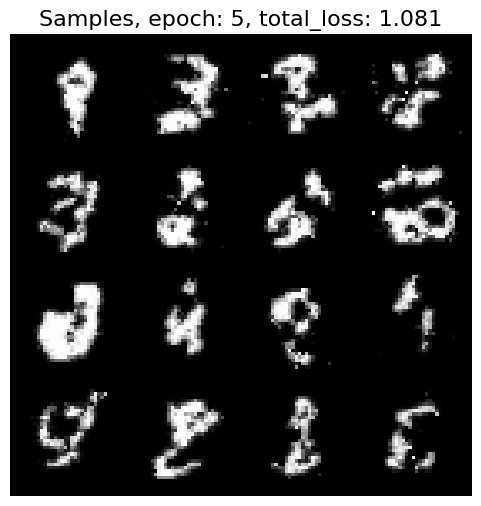

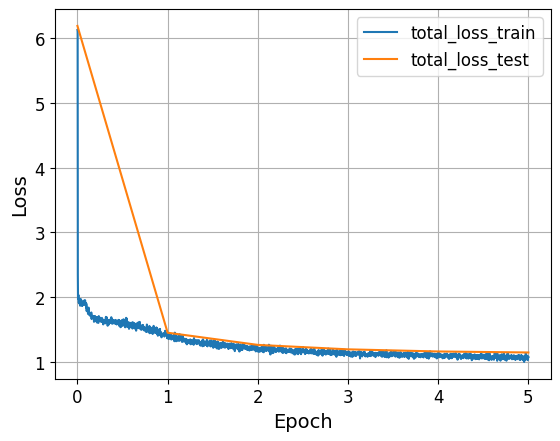

End of the training


In [ ]:
# ====
# your code
# choose these parameters
EPOCHS = 5
BATCH_SIZE = 128
LR = 5e-3

EMB_DIM = 128
NUM_HEADS = 8
NUM_LAYERS = 6
# ====

any_order_gpt = AnyOrderImageGPT((32, 32), EMB_DIM, NUM_HEADS, NUM_LAYERS)

train_loader = data.DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
test_loader = data.DataLoader(test_data, batch_size=BATCH_SIZE)

optimizer = torch.optim.Adam(any_order_gpt.parameters(), lr=LR)

train_model(
    any_order_gpt,
    train_loader,
    test_loader,
    epochs=EPOCHS,
    optimizer=optimizer,
    device=DEVICE,
    n_samples=16,  # Remember the inference is slow, so, you can lower the value
    # or you can turn off sampling by setting `visualize_samples=False`
    visualize_samples=True,
    use_amp=True
)

Now sample a few images in random pixel orders.


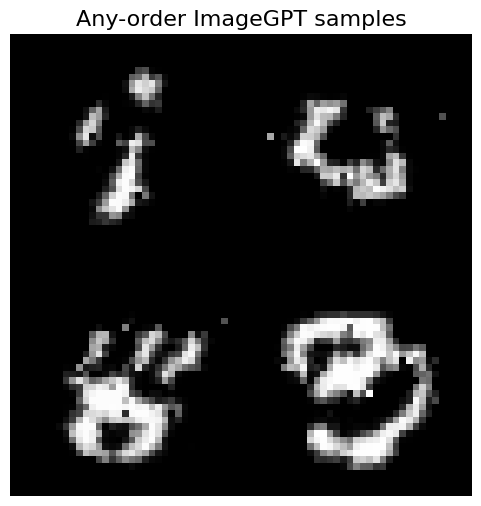

In [39]:
samples = any_order_gpt.sample(4)
show_samples(samples, title="Any-order ImageGPT samples", nrow=2)

Due to the additional stochasticity (in terms of permutation $\pi$), any-order ImageGPT requires much longer training and a larger batch size. Don’t be discouraged if the generated images look worse.

## Task 4: TarFlow on MNIST (5 pts)

In this task, you will implement a small **Transformer Autoregressive Flow (TarFlow)** on MNIST. TarFlow is a recent normalizing flow model that achieves results competitive with state-of-the-art generative methods. For more details, read the [TarFlow paper](https://arxiv.org/abs/2412.06329) and revisit [Lecture 2](https://github.com/r-isachenko/2026-DGM-MIPT-YSDA-course/blob/main/lectures/lecture2/Lecture2.pdf) for the change-of-variables formula.

Let's prepare some continuous MNIST data.

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 507kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.61MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.0MB/s]


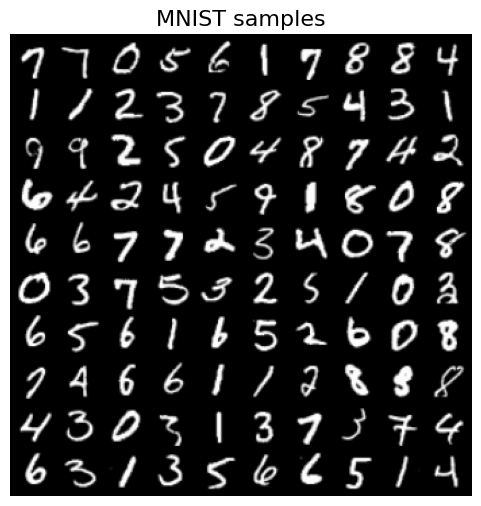

In [4]:
train_data, _, test_data, _ = load_dataset(
    "mnist", flatten=False, binarize=False)
visualize_images(train_data, "MNIST samples")

### Architecture

Let us first implement a single TarFlowBlock. As discussed in [Lecture 2](https://github.com/r-isachenko/2026-DGM-MIPT-YSDA-course/blob/main/lectures/lecture2/Lecture2.pdf), normalizing flows use invertible transformations. TarFlow uses an autoregressive construction to define an invertible transformation of image patches.

Let $x_i\in\mathbb{R}^D$ be the $i$-th input patch (out of $N$ in total). A causal Transformer predicts a shift $\mu_i$ and a log-scale $\alpha_i$ from the preceding patches. The block applies

$$
z_0=x_0,\qquad
z_i=\bigl(x_i-\mu_i(x_{<i})\bigr)\exp\bigl(-\alpha_i(x_{<i})\bigr),
\quad i>0.
$$

The Jacobian is triangular, with diagonal entries $\exp(-\alpha_{i,j})$ for $i>0$. Therefore,

$$
\log|\det J|=-\sum_{i=1}^{N-1}\sum_{j=1}^{D}\alpha_{i,j}.
$$

We will reuse the causal `TransformerBlock` from Task 2 to predict the shifts and log-scales. Let us now implement `TarFlowBlock`.

In [9]:
class TarFlowBlock(nn.Module):
    def __init__(
        self,
        patch_dim: int,
        num_patches: int,
        embed_dim: int,
        num_heads: int,
        num_layers: int,
        reverse_order: bool,
    ) -> None:
        super().__init__()
        self.reverse_order = reverse_order

        # ====
        # your code
        # 1) define projecting layer for each patch from patch_dim to embed_dim
        # 2) define learned positional embeddings of shape (1, num_patches, embed_dim)
        # 3) stack num_layers TransformerBlock instances
        # 4) define a head that predicts a shift and a log-scale for each patch
        # NOTE: initialize the head's weight and bias to zero so the flow block
        # starts as the identity transformation; this will improve stability of training
        self.patch_dim = patch_dim
        self.num_patches = num_patches
        self.embed_dim = embed_dim

        self.proj = nn.Linear(patch_dim, embed_dim)
        self.positional_embeddings = nn.Embedding(num_patches, embed_dim)
        self.layers = nn.ModuleList()
        for _ in range(num_layers):
            self.layers.append(TransformerBlock(embed_dim, num_heads))
        self.head = nn.Linear(embed_dim, 2 * patch_dim)
        nn.init.zeros_(self.head.weight)
        nn.init.zeros_(self.head.bias)
        # ====

    def predict_parameters(self, x: torch.Tensor) -> torch.Tensor:
        # NOTE: Transformer need not be invertible; it only predicts
        # the parameters of the affine transformation.
        length = x.size(1)

        # ====
        # your code
        # 1) arrange positional embeddings in the same order as the patches in x
        # 2) cut positional embeddings by length of x
        #    (during inverse/generation, x is a partial sequence)
        # 3) project the patches to embed_dim and add their positional embeddings
        # 4) apply Transformer blocks (don't forget to transpose embeddings)
        # 5) apply head
        pos_ind = torch.arange(length, device=x.device)
        pos_emb = self.positional_embeddings(
            pos_ind)  # (num_patches, embed_dim)
        x_proj = self.proj(x)  # (batch_size, num_patches, embed_dim)
        # (batch_size, num_patches, embed_dim)
        embeddings = x_proj + pos_emb[None, :, :]
        # (num_patches, batch_size, embed_dim)
        embeddings = embeddings.permute(1, 0, 2)
        for layer in self.layers:
            embeddings = layer(embeddings)
        # (num_patches, batch_size, 2 patch_dim)
        parameters = self.head(embeddings)
        # ====
        return parameters.permute(1, 0, 2)

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        if self.reverse_order:
            x = x.flip(1)

        # ====
        # your code
        # 1) predict parameters and shift them right
        #    (parameters for x_i must depend only on x_<i)
        # 2) apply the affine transformation and compute log-determinant
        parameters = self.predict_parameters(x)
        batch_size = parameters.shape[0]
        m, a = parameters.chunk(2, dim=-1)
        m = torch.concat([torch.zeros(
            batch_size, 1, self.patch_dim, device=x.device), m[:, :-1, :]], dim=1)
        a = torch.concat([torch.zeros(
            batch_size, 1, self.patch_dim, device=x.device), a[:, :-1, :]], dim=1)
        z = (x - m) * torch.exp(-a)  # (batch_size, num_patches, patch_dim)
        log_det = -a.sum(dim=(1, 2))
        # ====

        if self.reverse_order:
            z = z.flip(1)
        return z, log_det

    def inverse(self, z: torch.Tensor) -> torch.Tensor:
        if self.reverse_order:
            z = z.flip(1)

        # ====
        # your code
        # 1) copy the first patch (it unchanged by the formula)
        # 2) for each next patch, predict its parameters from the reconstructed prefix
        #    (use the last prediction, which forward shifts to that patch)
        # 3) apply inverted affine transformation and append the recovered patch to x
        x = z[:, 0, :][:, None, :]
        for i in range(1, self.num_patches):
            parameters = self.predict_parameters(x)
            m, a = parameters.chunk(2, dim=-1)
            m = m[:, -1, :]
            a = a[:, -1, :]
            x_i = z[:, i, :] * torch.exp(a) + m
            x = torch.concat([x, x_i[:, None, :]], dim=1)
        # ====

        return x.flip(1) if self.reverse_order else x


def test_tarflow_block() -> None:
    block = TarFlowBlock(
        patch_dim=2, num_patches=4, embed_dim=12,
        num_heads=4, num_layers=1, reverse_order=True,
    )
    with torch.no_grad():
        block.head.weight.normal_(std=0.01)
        block.head.bias.normal_(std=0.01)

    x = torch.randn(2, 4, 2)
    z, log_det = block(x)
    assert z.shape == x.shape and log_det.shape == (2,)
    assert torch.allclose(block.inverse(z), x, atol=1e-5)

    ordered_x = x.flip(1)
    parameters = block.predict_parameters(ordered_x)
    changed_x = ordered_x.clone()
    changed_x[:, 2:] += 1.0
    changed_parameters = block.predict_parameters(changed_x)
    assert torch.allclose(
        parameters[:, :2], changed_parameters[:, :2], atol=1e-6)


test_tarflow_block()

The full TarFlow model splits an image into patches, applies several `TarFlowBlock`s with alternating patch order (so a patch left unchanged by one block can be transformed by the next), and evaluates the resulting latent under a standard Gaussian prior.

Now let us implement it.

In [10]:
class TarFlow(BaseModel):
    def __init__(
        self,
        input_shape: tuple[int, int],
        n_channels: int,
        patch_size: int,
        embed_dim: int,
        num_heads: int,
        num_layers: int,
        num_blocks: int,
    ) -> None:
        super().__init__()
        assert input_shape[0] % patch_size == 0 and input_shape[1] % patch_size == 0
        self.input_shape = input_shape
        self.n_channels = n_channels
        self.patch_size = patch_size
        num_patches = (input_shape[0] // patch_size) * \
            (input_shape[1] // patch_size)
        patch_dim = n_channels * patch_size * patch_size

        self.prior = torch.distributions.Normal(
            loc=torch.tensor(0.0), scale=torch.tensor(1.0)
        )
        # ====
        # your code
        # stack flow blocks with alternating forward and reversed patch order
        self.I = input_shape[0] // self.patch_size
        self.J = input_shape[1] // self.patch_size
        self.layers = nn.ModuleList()
        for i in range(num_blocks):
            self.layers.append(TarFlowBlock(
                patch_dim, num_patches, embed_dim, num_heads, num_layers, reverse_order=bool(i % 2)))
        # ====

    def patchify(self, x: torch.Tensor) -> torch.Tensor:
        # ====
        # your code
        # split the image into non-overlapping patches without changing their values
        # ====
        B, C, _, _ = x.shape
        I, J = self.I, self.J
        P = self.patch_size
        patches = torch.empty(B, I * J, C * P * P, device=x.device)
        for i in range(I):
            for j in range(J):
                block = x[:, :, i*P:(i+1)*P, j*P:(j+1)*P]  # (B, C, P, P)
                patches[:, i * J + j] = block.reshape(B, -1)
        return patches

    def unpatchify(self, patches: torch.Tensor) -> torch.Tensor:
        # ====
        # your code
        # put the patch vectors back at their original image positions
        B = patches.shape[0]
        I = self.I
        J = self.J
        P = self.patch_size
        C = patches.shape[-1] // P ** 2
        x = torch.empty(B, C, I * P, J * P, device=patches.device)
        for i in range(I):
            for j in range(J):
                x[:, :, i*P:(i+1)*P, j*P:(j+1)*P] = patches[:,
                                                            i * J + j].reshape(B, C, P, P)
        # ====
        return x

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        # NOTE: we scale images from [0, 1] to [-1, 1]
        # this adds C * H * W * log(2) to the log-determinant
        x = 2 * x - 1
        log_det = x.new_full((x.size(0),), x[0].numel() * np.log(2.0))

        # ====
        # your code
        # 1) prepare image patches
        # 2) apply all flow blocks and accumulate their log-determinants
        # 3) unpachify to obtain latent
        patches = self.patchify(x)
        for layer in self.layers:
            patches, log_det_i = layer(patches)
            log_det += log_det_i
        z = self.unpatchify(patches)
        # ====

        return z, log_det

    def inverse(self, z: torch.Tensor) -> torch.Tensor:
        # ====
        # your code
        # 1) prepare latent patches
        # 2) apply all invesed flow blocks
        # 3) unpachify to obtain image
        patches = self.patchify(z)
        for layer in self.layers[::-1]:
            patches = layer.inverse(patches)
        x = self.unpatchify(patches)
        # ====
        return (x + 1) / 2

    def log_prob(self, x: torch.Tensor) -> torch.Tensor:
        self.prior.loc = self.prior.loc.to(self.device)
        self.prior.scale = self.prior.scale.to(self.device)
        # ====
        # your code
        # compute log probability of x using CoV formula
        # use self.prior to compute log probability of latent
        z, log_det = self.forward(x)
        log_prob = self.prior.log_prob(z).flatten(
            start_dim=1).sum(dim=1) + log_det
        # ====
        return log_prob

    def loss(self, x: torch.Tensor) -> dict:
        return {"nll_loss": -self.log_prob(x).mean()}

    @torch.no_grad()
    def sample(self, num_samples: int) -> np.ndarray:
        z = torch.randn(num_samples, self.n_channels, *
                        self.input_shape, device=self.device)
        samples = self.inverse(z).cpu().numpy()
        return np.clip(samples, 0.0, 1.0)


def test_tarflow() -> None:
    model = TarFlow(
        input_shape=(4, 4), n_channels=1, patch_size=2,
        embed_dim=12, num_heads=4, num_layers=1, num_blocks=2,
    )
    x = torch.randn(2, 1, 4, 4)
    assert torch.equal(model.unpatchify(model.patchify(x)), x)

    x = torch.rand(2, 1, 4, 4)
    x[0, 0, 0, 0] = 0.0
    x[0, 0, 0, 1] = 1.0
    z, log_det = model(x)
    assert z.shape == x.shape and log_det.shape == (2,)
    assert torch.allclose(log_det, torch.full_like(log_det, 16 * np.log(2.0)))
    assert torch.allclose(model.inverse(z), x, atol=1e-5)
    assert torch.isfinite(model.loss(x)["nll_loss"])


test_tarflow()

### Training

Now we are ready to train TarFlow.

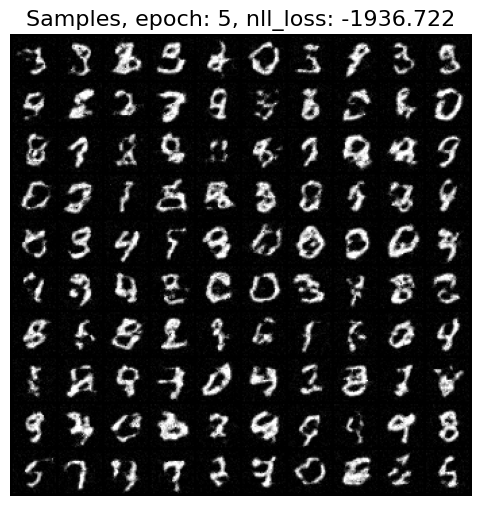

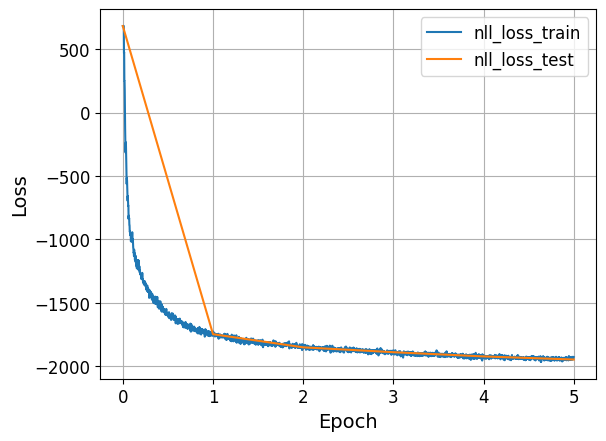

End of the training


In [11]:
# ====
# your code
# choose these parameters
EPOCHS = 5
BATCH_SIZE = 128
LR = 5e-4

PATCH_SIZE = 8
EMB_DIM = 128
NUM_HEADS = 8
NUM_LAYERS = 6
NUM_BLOCKS = 6
# ====

tarflow = TarFlow(
    input_shape=(32, 32),
    n_channels=1,
    patch_size=PATCH_SIZE,
    embed_dim=EMB_DIM,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
    num_blocks=NUM_BLOCKS,
)

# we add Gaussian noise to smooth the many exact zeros in MNIST
# this helps the flow learn a continuous density and improves sample quality


class GaussianNoiseDataset(data.Dataset):
    def __init__(self, images, noise_std_scaled: float) -> None:
        self.images = images
        self.noise_std = noise_std_scaled / 2

    def __len__(self) -> int:
        return len(self.images)

    def __getitem__(self, index: int) -> torch.Tensor:
        x = torch.as_tensor(self.images[index], dtype=torch.float32)
        return x + self.noise_std * torch.randn_like(x)


train_loader = data.DataLoader(
    GaussianNoiseDataset(train_data, 0.05), batch_size=BATCH_SIZE, shuffle=True
)
test_loader = data.DataLoader(
    GaussianNoiseDataset(test_data, 0.05), batch_size=BATCH_SIZE
)

# choose any optimizer/scheduler as you want
optimizer = torch.optim.AdamW(tarflow.parameters(), lr=LR)

train_model(
    tarflow,
    train_loader,
    test_loader,
    epochs=EPOCHS,
    optimizer=optimizer,
    gradient_clip_val=1.0,
    device=DEVICE,
    visualize_samples=True,
    loss_key="nll_loss",
    use_amp=True,
)

Finally, let's draw samples from TarFlow.

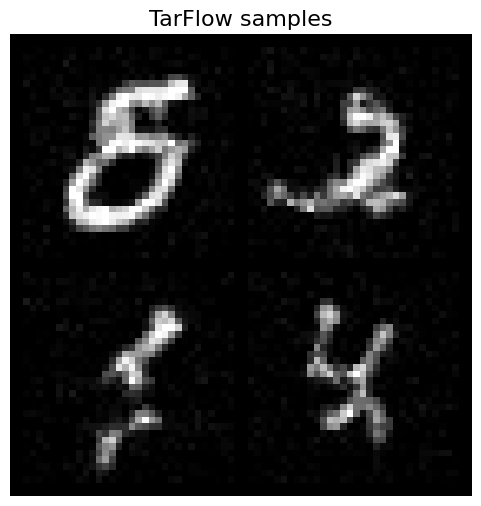

In [12]:
samples = tarflow.sample(4)
show_samples(samples, title="TarFlow samples", nrow=2)